In [10]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

In [11]:
plt.style.use('ggplot')
plt.style.use('fivethirtyeight')

def mean_absolute_percentage_error(y_true, y_pred): 
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [12]:
pjme = pd.read_csv('C:/Users/maxar/OneDrive/Documents/Python Trading Algo/AEP_hourly.csv',
                   index_col=[0],
                  parse_dates=[0])
pjme.head()

C:\Users\maxar\AppData\Local\Temp\ipykernel_19188\3817646372.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  pjme = pd.read_csv('C:/Users/maxar/OneDrive/Documents/Python Trading Algo/AEP_hourly.csv',


,AEP_MW
Datetime,
2004-12-31 01:00:00,13478
2004-12-31 02:00:00,12865
2004-12-31 03:00:00,12577
2004-12-31 04:00:00,12517
2004-12-31 05:00:00,12670


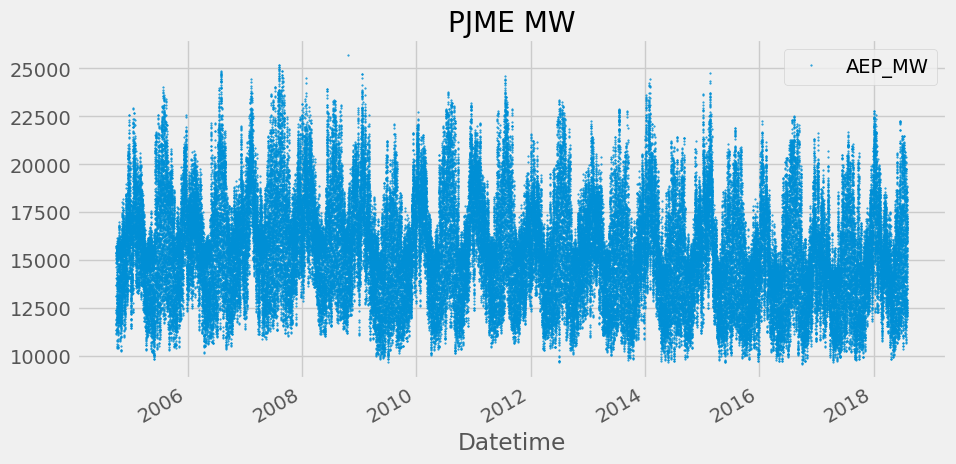

In [13]:
color_pal = sns.color_palette()
pjme.plot(style='.',
          figsize=(10, 5),
          ms=1,
          color=color_pal[0],
          title='PJME MW')
plt.show()

In [14]:
from pandas.api.types import CategoricalDtype

cat_type = CategoricalDtype(categories=['Monday','Tuesday',
                                        'Wednesday',
                                        'Thursday','Friday',
                                        'Saturday','Sunday'],
                            ordered=True)

def create_features(df, label=None):
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(cat_type)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300

    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300], 
                          labels=['Spring', 'Summer', 'Fall', 'Winter']
                   )
    X = df[['hour','dayofweek','quarter','month','year',
           'dayofyear','dayofmonth','weekday',
           'season']]
    if label:
        y = df[label]
        return X, y
    return X

X, y = create_features(pjme, label='AEP_MW')
features_and_target = pd.concat([X, y], axis=1)

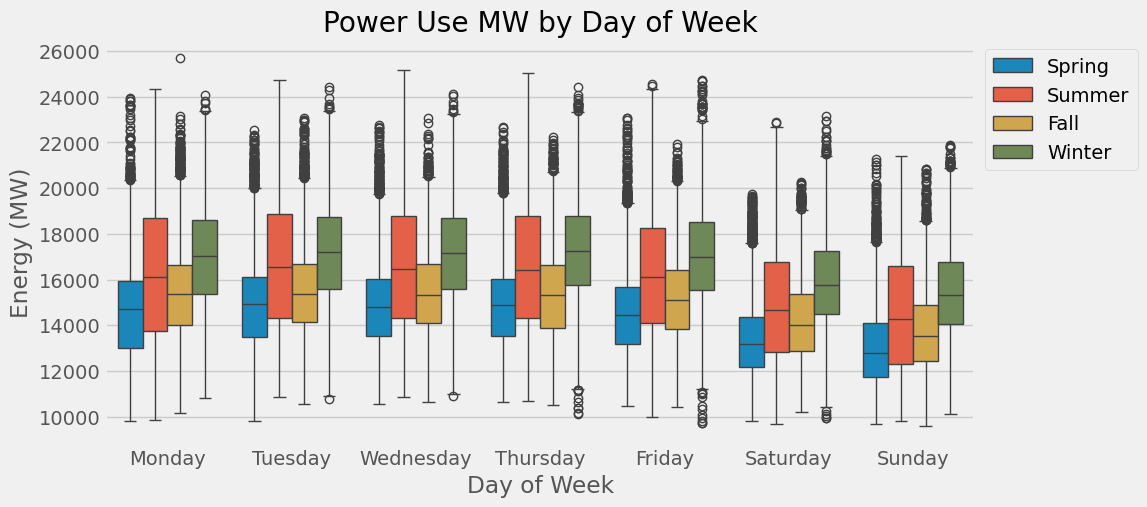

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=features_and_target.dropna(),
            x='weekday',
            y='AEP_MW',
            hue='season',
            ax=ax,
            linewidth=1)
ax.set_title('Power Use MW by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Energy (MW)')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

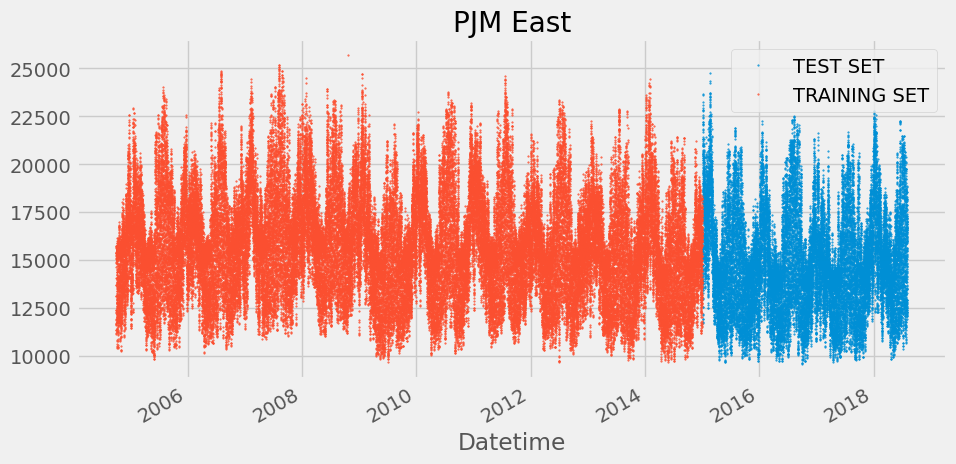

In [16]:
split_date = '1-Jan-2015'
pjme_train = pjme.loc[pjme.index <= split_date].copy()
pjme_test = pjme.loc[pjme.index > split_date].copy()

# Plot train and test so you can see where we have split
pjme_test \
    .rename(columns={'AEP_MW': 'TEST SET'}) \
    .join(pjme_train.rename(columns={'AEP_MW': 'TRAINING SET'}),
          how='outer') \
    .plot(figsize=(10, 5), title='PJM East', style='.', ms=1)
plt.show()

In [21]:
pjme_train_prophet = pjme_train.reset_index() \
    .rename(columns={'Datetime':'ds',
                     'AEP_MW':'y'})

In [22]:
%%time
model = Prophet()
model.fit(pjme_train_prophet)

16:45:02 - cmdstanpy - INFO - Chain [1] start processing
16:46:52 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 3.59 s
Wall time: 2min 6s


In [24]:
# Predict on test set with model
pjme_test_prophet = pjme_test.reset_index() \
    .rename(columns={'Datetime':'ds',
                     'AEP_MW':'y'})

pjme_test_fcst = model.predict(pjme_test_prophet)


In [25]:
pjme_test_fcst.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 01:00:00,15025.061783,12820.805105,16476.891843,15025.061783,15025.061783,-325.344568,-325.344568,-325.344568,-1526.606812,...,601.259244,601.259244,601.259244,600.003000,600.003000,600.003000,0.0,0.0,0.0,14699.717214
1,2015-01-01 02:00:00,15025.046468,12382.857639,16133.390874,15025.046468,15025.046468,-920.045694,-920.045694,-920.045694,-2123.340631,...,602.245774,602.245774,602.245774,601.049163,601.049163,601.049163,0.0,0.0,0.0,14105.000774
2,2015-01-01 03:00:00,15025.031153,11711.154483,15725.765640,15025.031153,15025.031153,-1261.232936,-1261.232936,-1261.232936,-2465.901827,...,602.546109,602.546109,602.546109,602.122782,602.122782,602.122782,0.0,0.0,0.0,13763.798216
3,2015-01-01 04:00:00,15025.015838,11823.606450,15558.436512,15025.015838,15025.015838,-1299.475848,-1299.475848,-1299.475848,-2504.866710,...,602.167009,602.167009,602.167009,603.223852,603.223852,603.223852,0.0,0.0,0.0,13725.539990
4,2015-01-01 05:00:00,15025.000523,12165.780568,15941.541202,15025.000523,15025.000523,-1002.630333,-1002.630333,-1002.630333,-2208.105968,...,601.123265,601.123265,601.123265,604.352370,604.352370,604.352370,0.0,0.0,0.0,14022.370190


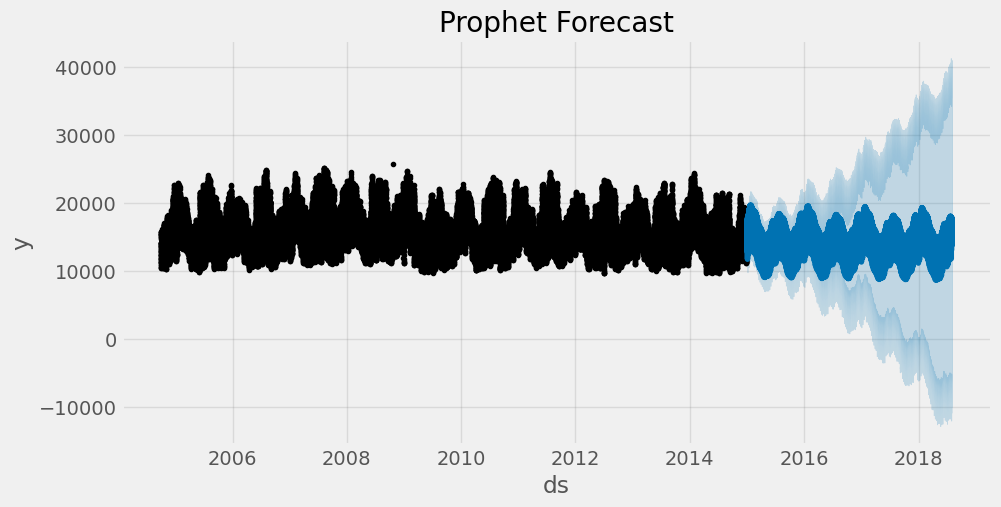

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_title('Prophet Forecast')
plt.show()

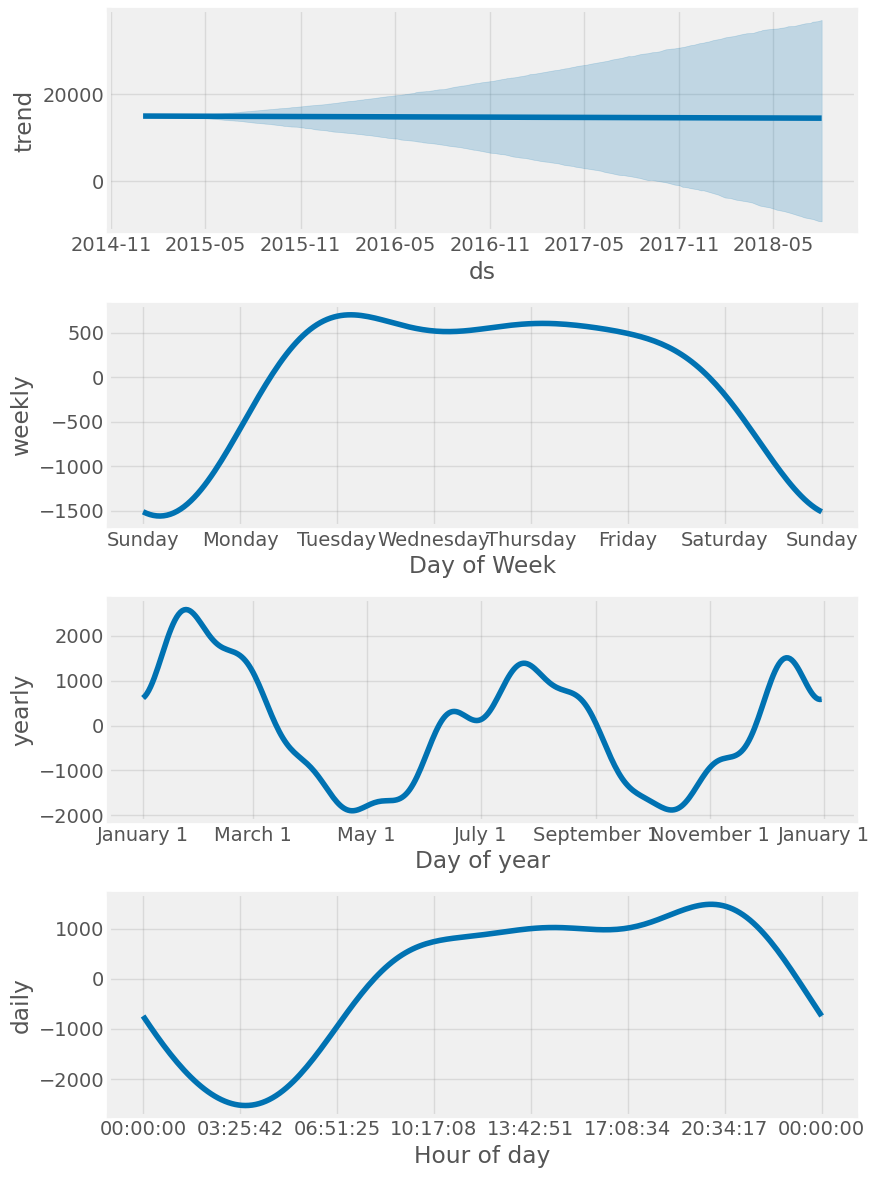

In [27]:
fig = model.plot_components(pjme_test_fcst)
plt.show()

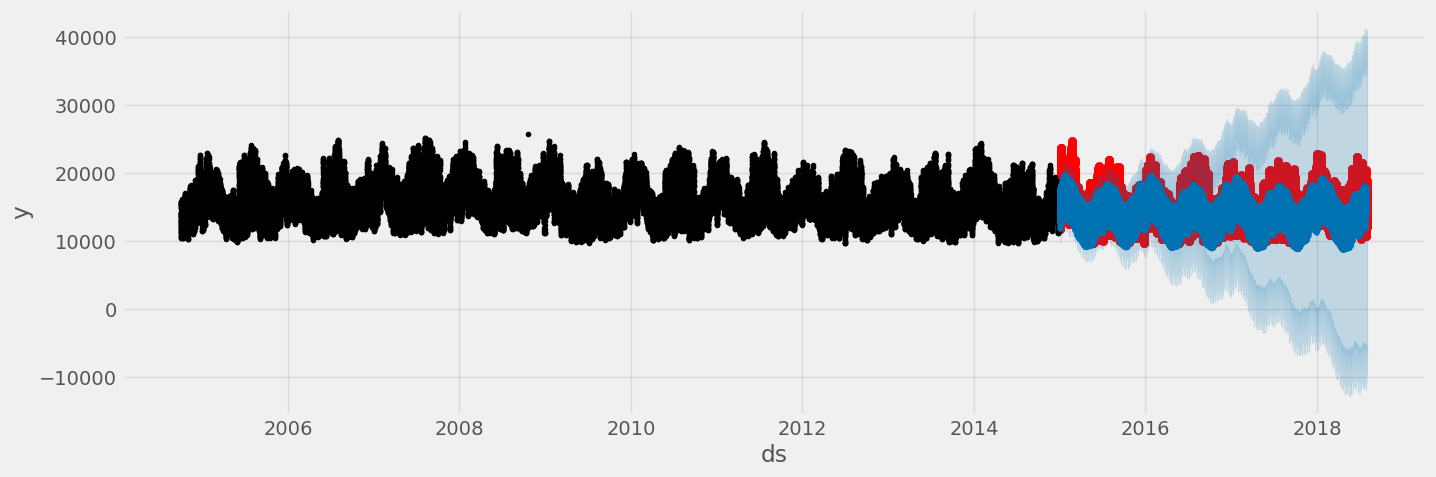

In [29]:
# Plot the forecast with the actuals
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(pjme_test.index, pjme_test['AEP_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)

ConversionError: Failed to convert value(s) to axis units: '01-01-2015'

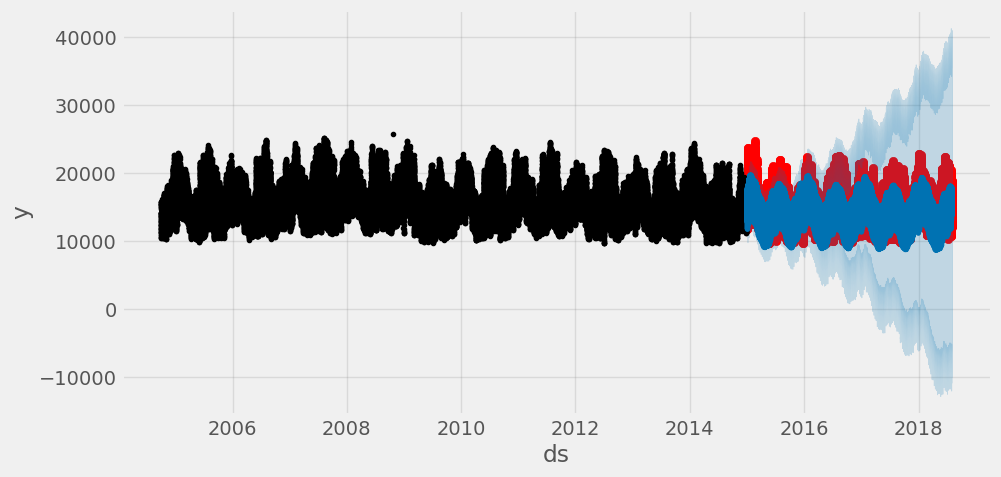

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pjme_test.index, pjme_test['AEP_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xbound(lower='01-01-2015',
              upper='02-01-2015')
ax.set_ylim(0, 60000)
plot = plt.suptitle('January 2015 Forecast vs Actuals')

ConversionError: Failed to convert value(s) to axis units: '01-01-2015'

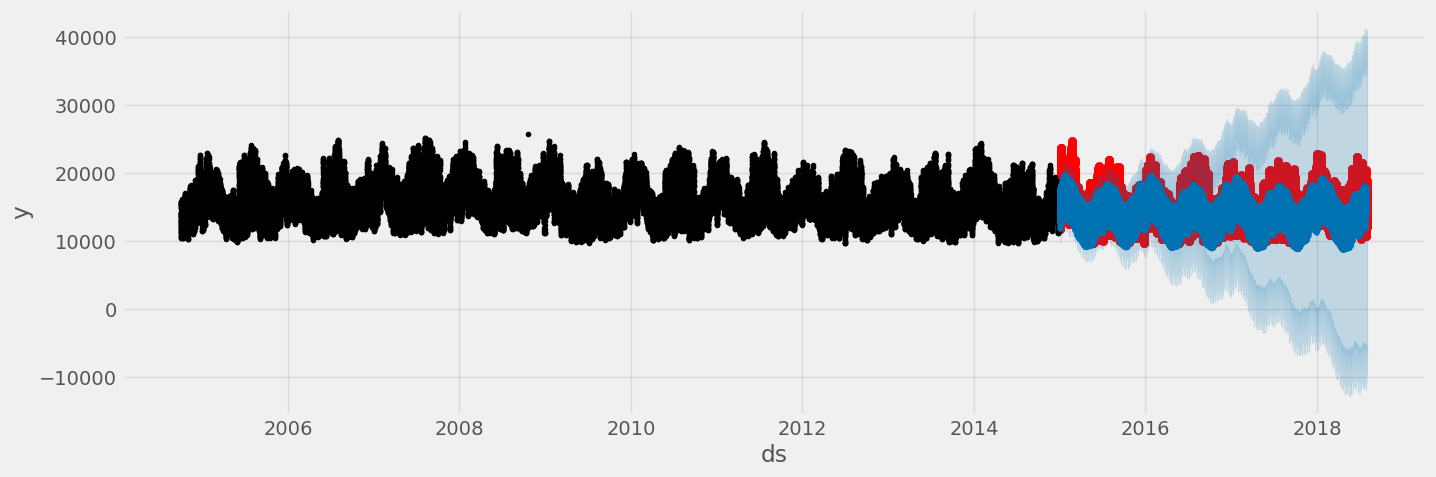

In [32]:
# Plot the forecast with the actuals
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(pjme_test.index, pjme_test['AEP_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xbound(lower='01-01-2015', upper='01-08-2015')
ax.set_ylim(0, 60000)
ax.set_title('First Week of January Forecast vs Actuals')
plt.show()

In [33]:
np.sqrt(mean_squared_error(y_true=pjme_test['AEP_MW'],
                   y_pred=pjme_test_fcst['yhat']))

2603.350037662485

In [34]:
mean_absolute_error(y_true=pjme_test['AEP_MW'],
                   y_pred=pjme_test_fcst['yhat'])

2080.9091821163806

In [35]:
mean_absolute_percentage_error(y_true=pjme_test['AEP_MW'],
                   y_pred=pjme_test_fcst['yhat'])

14.177690267400243